In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [9]:
expenses = pd.read_csv("Expenses_Processed.csv")
income = pd.read_csv("Income_Processed.csv")

In [10]:
expenses["date_time"] = pd.to_datetime(expenses["date_time"])
income["date_time"] = pd.to_datetime(income["date_time"])

In [7]:
expenses.head()
income.head()

,date_time,category,account,amount,currency,tags,Year,Month,Month_Name,Day,Day_Name,Weekday
0,2025-11-29,Job,acct_1,49.0,BYN,tag_1,2025,11,November,29,Saturday,5
1,2025-11-29,Job,acct_1,18.0,BYN,tag_2,2025,11,November,29,Saturday,5
2,2025-11-29,Job,acct_1,32.0,BYN,tag_3,2025,11,November,29,Saturday,5
3,2025-11-29,Job,acct_1,109.0,BYN,tag_4,2025,11,November,29,Saturday,5
4,2025-11-28,Second work,acct_1,132.0,BYN,2th_work,2025,11,November,28,Friday,4


In [11]:
expenses.info()
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938 entries, 0 to 937
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date_time   938 non-null    datetime64[ns]
 1   category    938 non-null    object        
 2   account     938 non-null    object        
 3   amount      938 non-null    float64       
 4   currency    938 non-null    object        
 5   tags        938 non-null    object        
 6   Year        938 non-null    int64         
 7   Month       938 non-null    int64         
 8   Month_Name  938 non-null    object        
 9   Day         938 non-null    int64         
 10  Day_Name    938 non-null    object        
 11  Weekday     938 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 88.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dty

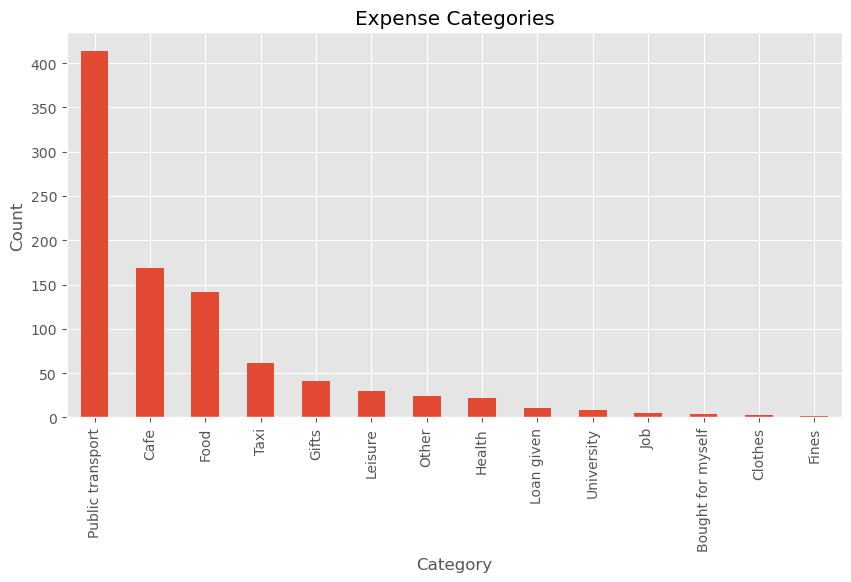

In [12]:
plt.figure(figsize=(10,5))

expenses["category"].value_counts().plot(kind="bar")

plt.title("Expense Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

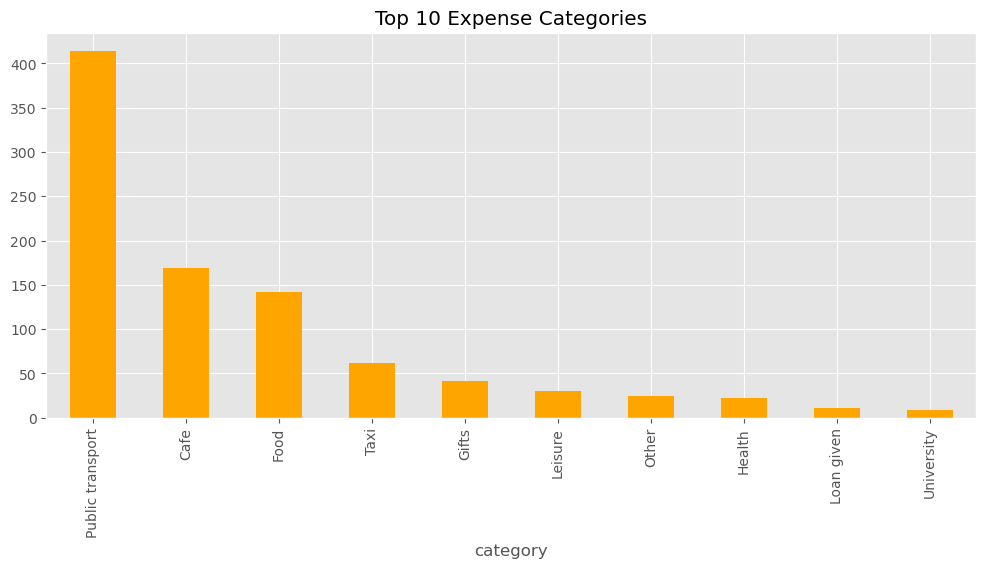

In [13]:
top = expenses["category"].value_counts().head(10)

plt.figure(figsize=(12,5))

top.plot(kind="bar", color="orange")

plt.title("Top 10 Expense Categories")

plt.show()

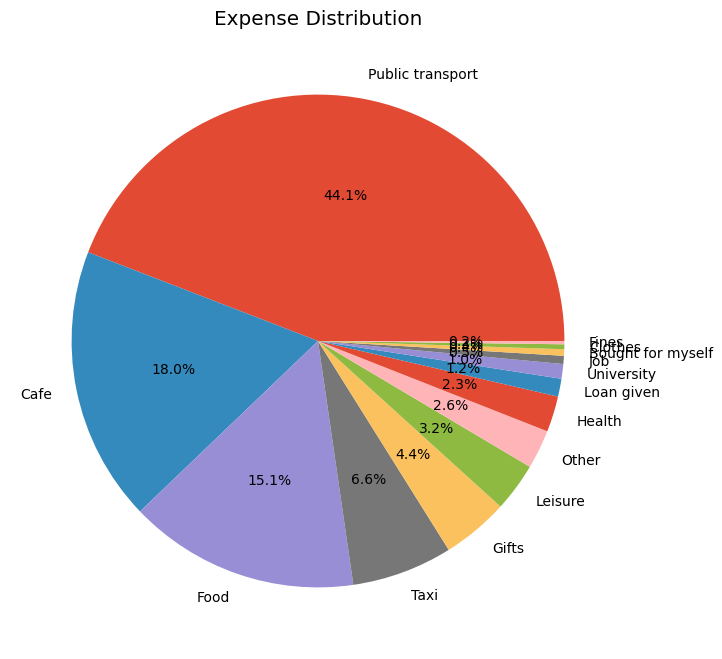

In [14]:
expenses["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.ylabel("")

plt.title("Expense Distribution")

plt.show()

In [15]:
monthly = expenses.groupby("Month_Name")["amount"].sum()

monthly

Month_Name
April        1184.0
August        835.0
February      621.0
January       979.0
July          821.0
June          695.0
March        3291.0
May           642.0
November      904.0
October      1960.0
September    2928.0
Name: amount, dtype: float64

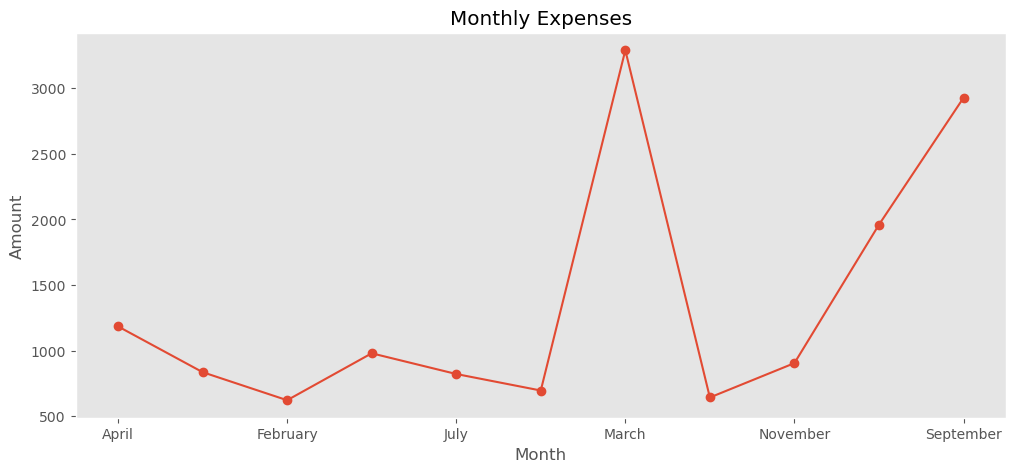

In [16]:
plt.figure(figsize=(12,5))

monthly.plot(marker="o")

plt.title("Monthly Expenses")

plt.xlabel("Month")

plt.ylabel("Amount")

plt.grid()

plt.show()

In [17]:
daily = expenses.groupby("Day_Name")["amount"].sum()

daily

Day_Name
Friday       1417.0
Monday       2174.0
Saturday     1300.0
Sunday       1251.0
Thursday     2030.0
Tuesday      1973.0
Wednesday    4715.0
Name: amount, dtype: float64

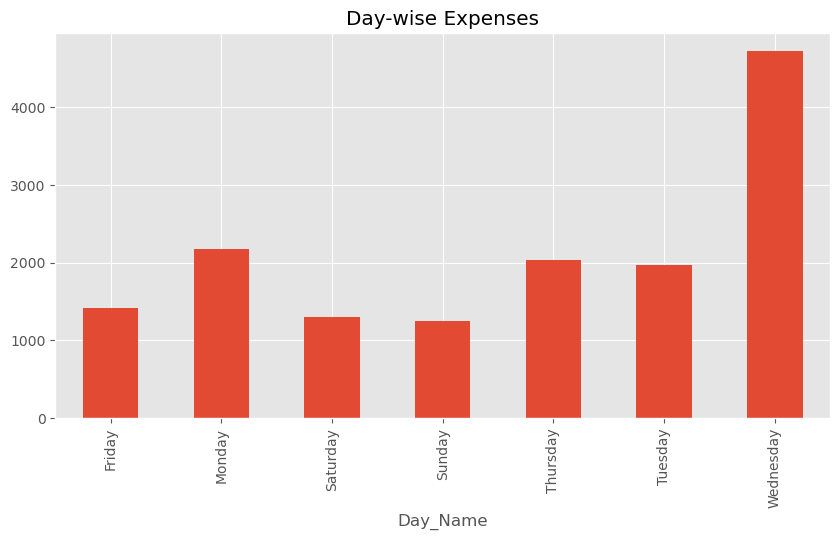

In [18]:
plt.figure(figsize=(10,5))

daily.plot(kind="bar")

plt.title("Day-wise Expenses")

plt.show()

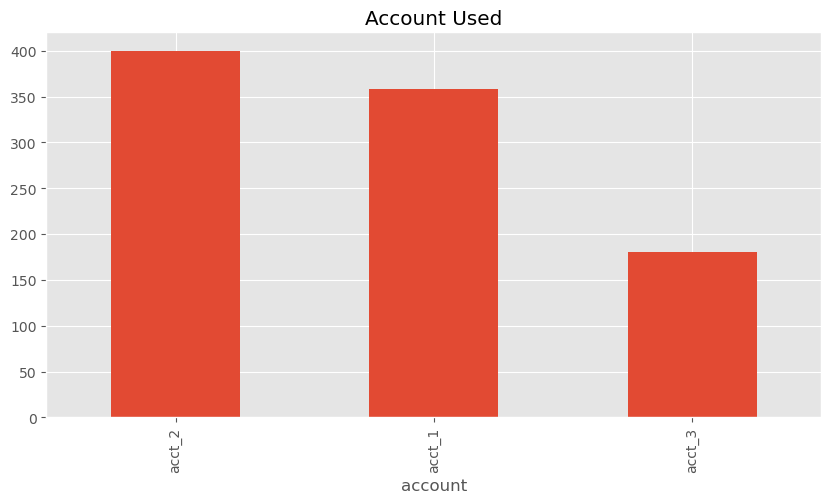

In [19]:
expenses["account"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Account Used")

plt.show()

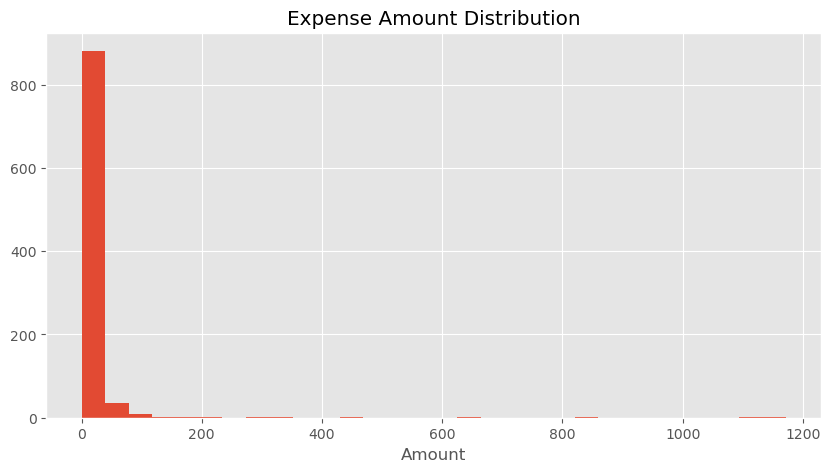

In [20]:
plt.figure(figsize=(10,5))

plt.hist(expenses["amount"], bins=30)

plt.title("Expense Amount Distribution")

plt.xlabel("Amount")

plt.show()

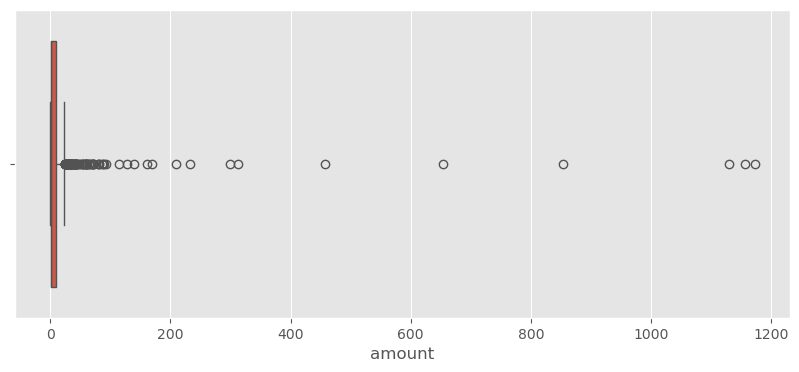

In [21]:
plt.figure(figsize=(10,4))

sns.boxplot(x=expenses["amount"])

plt.show()

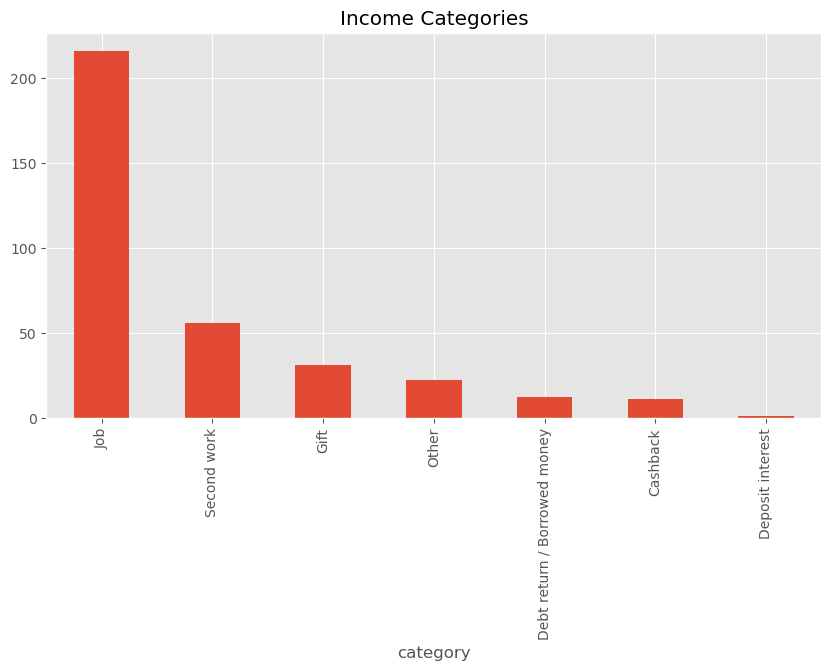

In [22]:
income["category"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Income Categories")

plt.show()

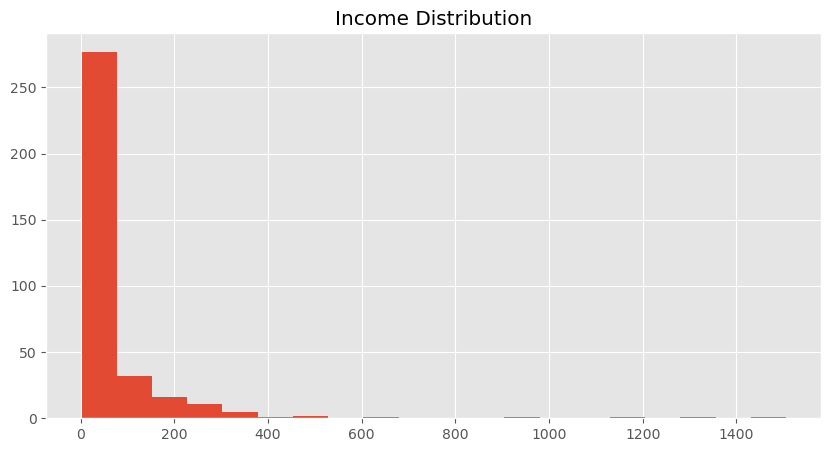

In [23]:
plt.figure(figsize=(10,5))

plt.hist(income["amount"], bins=20)

plt.title("Income Distribution")

plt.show()

In [24]:
income["amount"].sum()

np.float64(26629.0)

In [25]:
expenses["amount"].sum()

np.float64(14860.0)

In [26]:
total_income = income["amount"].sum()

total_expense = expenses["amount"].sum()

print("Income :", total_income)

print("Expense :", total_expense)

print("Savings :", total_income-total_expense)

Income : 26629.0
Expense : 14860.0
Savings : 11769.0


In [27]:
monthly_income = income.groupby("Month_Name")["amount"].sum()

monthly_income

Month_Name
April        1423.0
August       2359.0
February     1647.0
January      1864.0
July         1967.0
June         2227.0
March        3092.0
May          2010.0
November     1317.0
October      2993.0
September    5730.0
Name: amount, dtype: float64

In [28]:
comparison = pd.DataFrame({

    "Income":monthly_income,

    "Expense":monthly

})

comparison

,Income,Expense
Month_Name,,
April,1423.0,1184.0
August,2359.0,835.0
February,1647.0,621.0
January,1864.0,979.0
July,1967.0,821.0
June,2227.0,695.0
March,3092.0,3291.0
May,2010.0,642.0
November,1317.0,904.0


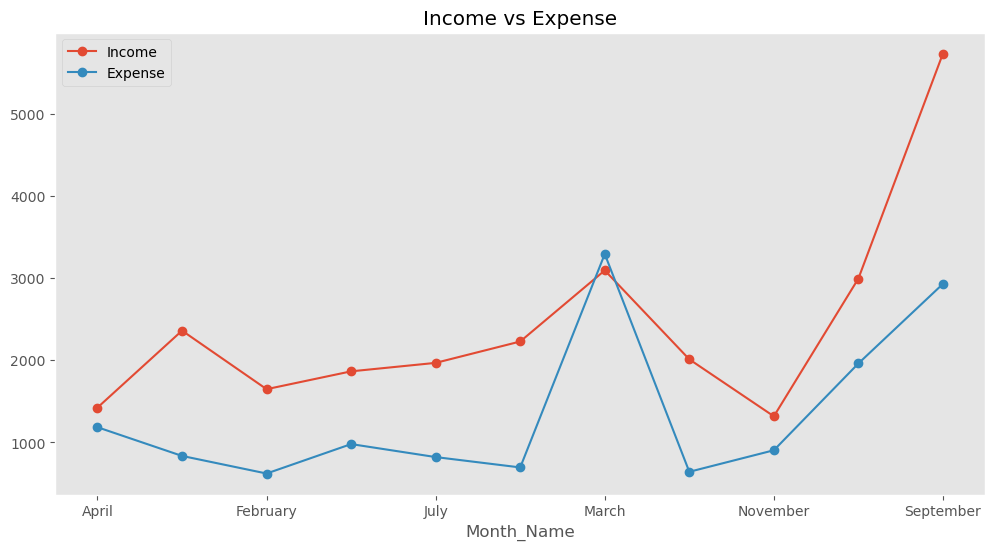

In [29]:
comparison.plot(

    figsize=(12,6),

    marker="o"

)

plt.title("Income vs Expense")

plt.grid()

plt.show()

In [30]:
expenses.corr(numeric_only=True)

,amount,Year,Month,Day,Weekday
amount,1.000000,NaN,-0.011582,0.002006,-0.002426
Year,NaN,NaN,NaN,NaN,NaN
Month,-0.011582,NaN,1.000000,-0.030821,0.054796
Day,0.002006,NaN,-0.030821,1.000000,0.073783
Weekday,-0.002426,NaN,0.054796,0.073783,1.000000


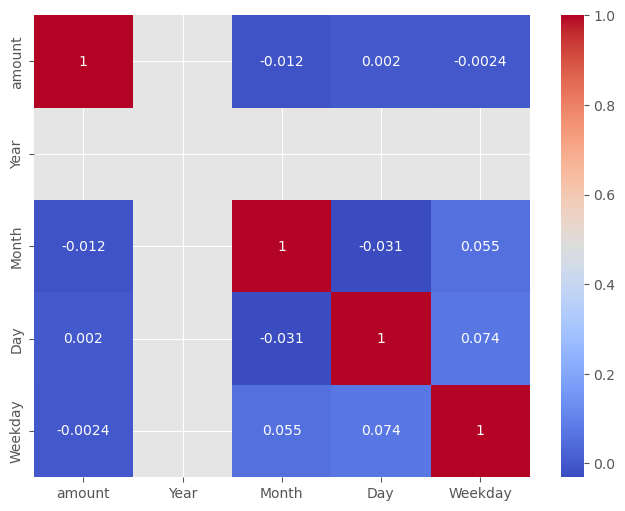

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(

    expenses.corr(numeric_only=True),

    annot=True,

    cmap="coolwarm"

)

plt.show()

In [32]:
expenses.head()

,date_time,category,account,amount,currency,tags,Year,Month,Month_Name,Day,Day_Name,Weekday
0,2025-11-30,Health,acct_1,114.0,BYN,tag_1,2025,11,November,30,Sunday,6
1,2025-11-29,Food,acct_1,5.0,BYN,tag_1,2025,11,November,29,Saturday,5
2,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,November,27,Thursday,3
3,2025-11-27,Cafe,acct_1,10.0,BYN,tag_1,2025,11,November,27,Thursday,3
4,2025-11-27,Public transport,acct_2,1.0,BYN,tag_1,2025,11,November,27,Thursday,3
